 # **Aim:-**

##### **To develop a machine learning model that can classify liver disease types (Hepatitis, Fibrosis, Cirrhosis) based on patients’ demographic details and biochemical test results, in order to assist in early detection, diagnosis, and better clinical decision-making.**

# **Loading the DataSet**

In [8]:
import pandas as pd

df= pd.read_csv(r"C:\Users\aryan\OneDrive\Desktop\AI Summer Training\DataSets\Hcv_project_data.csv")

df

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,811,1=Hepatitis,41,m,47.2,52.2,79.5,175.2,22.5,11.30,5.90,83.0,103.2,80.2
811,812,2=Fibrosis,53,f,37.9,NaN,113.2,175.2,10.9,7.90,3.70,72.0,163.2,74.2
812,813,3=Cirrhosis,57,m,28.2,129.2,44.5,223.2,103.2,2.60,3.10,111.0,377.2,60.2
813,814,1=Hepatitis,33,f,43.9,41.9,67.2,140.2,18.8,10.20,6.00,72.0,85.2,77.2


# **Data Information Gathering**


In [9]:
## Checking Null Values
print("Null Values in the dataset:- \n",df.isnull().sum())


Null Values in the dataset:- 
 Unnamed: 0     0
Category       0
Age            0
Sex            0
ALB            1
ALP           51
ALT            1
AST            0
BIL            0
CHE            0
CHOL          22
CREA           0
GGT            0
PROT           1
dtype: int64


In [10]:
##Checking Duplicates 
print("Duplicates in the dataset:-",df.duplicated().sum())

Duplicates in the dataset:- 0


In [11]:
## Checking the datatype 

df.dtypes

Unnamed: 0      int64
Category       object
Age             int64
Sex            object
ALB           float64
ALP           float64
ALT           float64
AST           float64
BIL           float64
CHE           float64
CHOL          float64
CREA          float64
GGT           float64
PROT          float64
dtype: object

In [12]:
df['Category'].value_counts()

Category
0=Blood Donor             533
3=Cirrhosis                96
1=Hepatitis                91
2=Fibrosis                 88
0s=suspect Blood Donor      7
Name: count, dtype: int64

In [13]:
##checking the skewness
print(f"ALB skewness: {df['ALB'].skew()}\n"
      f"ALP skewness: {df['ALP'].skew()}\n"
      f"ALT skewness: {df['ALT'].skew()}\n"
      f"AST skewness: {df['AST'].skew()}\n"
      f"BIL skewness: {df['BIL'].skew()}\n"
      f"CHE skewness: {df['CHE'].skew()}\n"
      f"CHOL skewness: {df['CHOL'].skew()}\n"
      f"CREA skewness: {df['CREA'].skew()}\n"
      f"GGT skewness: {df['GGT'].skew()}\n"
      f"PROT skewness: {df['PROT'].skew()}\n"
)


ALB skewness: -0.43963104443653056
ALP skewness: 3.0698367646171256
ALT skewness: 2.5595007826297875
AST skewness: 1.3758122403416793
BIL skewness: 3.689459137620992
CHE skewness: -0.37543168420598005
CHOL skewness: 0.2693213450622553
CREA skewness: 16.24237787754209
GGT skewness: 2.3754408106684526
PROT skewness: -1.00674973095623



### Interpretation of Each Feature’s Skewness

ALB: -0.44 → Slightly left-skewed, but close to normal.

ALP: 3.07 → Highly right-skewed, long tail on right.

ALT: 2.56 → Highly right-skewed.

AST: 1.37 → Moderately right-skewed.

BIL: 3.68 → Highly right-skewed.

CHE: -0.37 → Almost symmetric, tiny left skew.

CHOL: 0.27 → Very close to normal, slight right skew.

CREA: 16.24  → Extremely right-skewed (lots of outliers).

GGT: 2.38 → Highly right-skewed.

PROT: -1.00 → Moderately left-skewed.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  815 non-null    int64  
 1   Category    815 non-null    object 
 2   Age         815 non-null    int64  
 3   Sex         815 non-null    object 
 4   ALB         814 non-null    float64
 5   ALP         764 non-null    float64
 6   ALT         814 non-null    float64
 7   AST         815 non-null    float64
 8   BIL         815 non-null    float64
 9   CHE         815 non-null    float64
 10  CHOL        793 non-null    float64
 11  CREA        815 non-null    float64
 12  GGT         815 non-null    float64
 13  PROT        814 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 89.3+ KB


In [15]:
df.describe()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,815.000000,815.000000,814.000000,764.000000,814.000000,815.000000,815.000000,815.000000,793.000000,815.000000,815.000000,814.000000
mean,407.263804,48.414724,40.792015,69.224215,38.346069,67.702945,18.795337,8.012675,5.153594,82.109202,76.503067,71.879607
std,235.729404,10.755253,6.441883,28.884029,32.013080,67.950547,29.319858,2.517787,1.190171,44.231943,98.201001,6.510136
min,1.000000,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.400000,1.430000,8.000000,4.500000,44.800000
25%,203.500000,40.000000,37.800000,50.175000,18.225000,23.000000,5.900000,6.740000,4.350000,68.000000,18.200000,68.925000
50%,407.000000,48.000000,41.500000,64.450000,27.200000,30.000000,9.200000,8.290000,5.100000,78.000000,30.700000,72.250000
75%,611.500000,56.000000,45.000000,82.625000,47.400000,118.250000,16.550000,9.685000,5.930000,89.550000,93.450000,76.100000
max,815.000000,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


# **Data Cleaning**


In [16]:
## Droping Unnecessary Column

df.drop(columns='Unnamed: 0', inplace=True)

In [17]:
df

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,1=Hepatitis,41,m,47.2,52.2,79.5,175.2,22.5,11.30,5.90,83.0,103.2,80.2
811,2=Fibrosis,53,f,37.9,NaN,113.2,175.2,10.9,7.90,3.70,72.0,163.2,74.2
812,3=Cirrhosis,57,m,28.2,129.2,44.5,223.2,103.2,2.60,3.10,111.0,377.2,60.2
813,1=Hepatitis,33,f,43.9,41.9,67.2,140.2,18.8,10.20,6.00,72.0,85.2,77.2


In [18]:
## Filling Null Values by finding out the median values

df['ALB'] = df['ALB'].fillna(df['ALB'].median())
df['ALP'] = df['ALP'].fillna(df['ALP'].median())
df['CHOL'] = df['CHOL'].fillna(df['CHOL'].median())
df['PROT'] = df['PROT'].fillna(df['PROT'].median())
df['ALT'] = df['ALT'].fillna(df['ALT'].median())



In [19]:
df.isnull().sum()


Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [20]:
# Assuming your column is named 'Category'
# This will split the string at '=' and take only the part after '='

df['Category'] = df['Category'].astype(str).apply(lambda x: x.split('=')[-1])



# **Feature Engineering**

In [21]:
## Importing LabelEncoder for converting Categorical column such as "Category" to numerical form for easy analysis 

from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

df['Category']=encoder.fit_transform(df['Category'])





# **Data Visulaization**

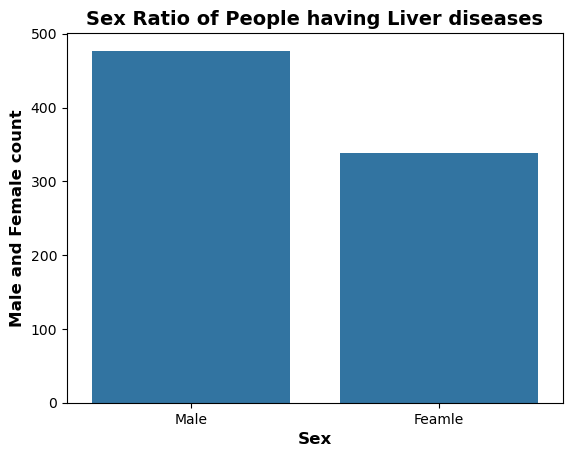

In [22]:
## Importing Seaborn and matplotib library for advanced visulaization
import seaborn as sns
import matplotlib.pyplot as plt

## CountPlot for determining  Sex

sns.countplot(x="Sex", data=df)
plt.title("Sex Ratio of People having Liver diseases",fontweight='bold', fontsize=14 )
plt.xlabel("Sex",fontweight='bold', fontsize=12 )
plt.ylabel("Male and Female count",fontweight='bold', fontsize=12 )
plt.xticks([0, 1], ["Male", "Feamle"])
plt.show()




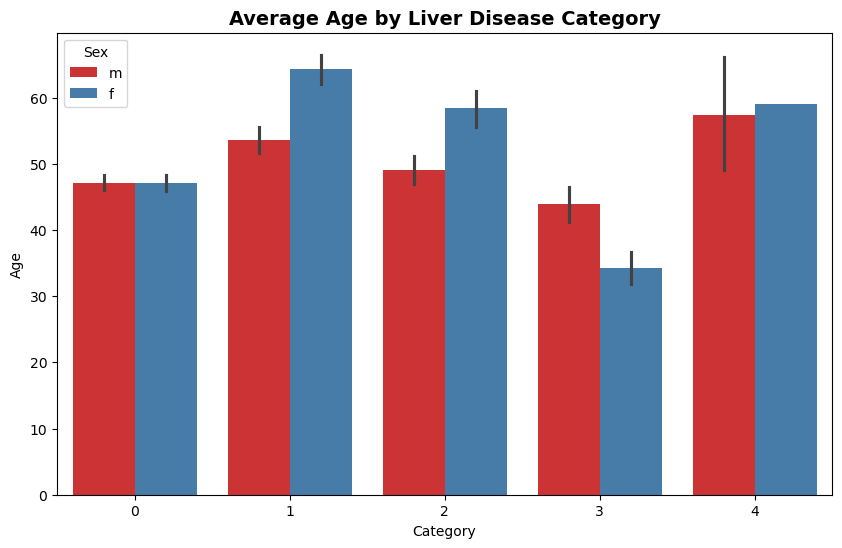

In [23]:
## Bar chart representing the liver diseases respect to the ages 

import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Age", data=df,hue='Sex', estimator="mean", palette="Set1")
plt.title("Average Age by Liver Disease Category", fontsize=14, fontweight="bold")
plt.show()


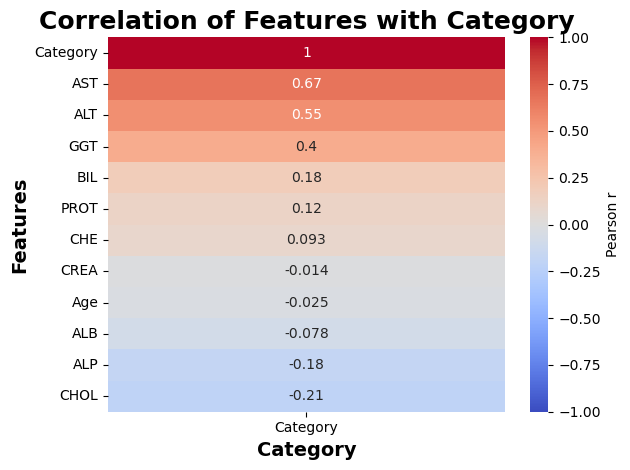

In [24]:
## Heatmap for finding the correlation of all the features with respect to the liver diseases

sns.heatmap(
    df.corr(numeric_only=True)[['Category']].sort_values('Category', ascending=False),
    annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label':'Pearson r'}
)
plt.title("Correlation of Features with Category",fontsize=18, fontweight="bold")
plt.xlabel("Category",fontsize=14, fontweight="bold")
plt.ylabel("Features",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


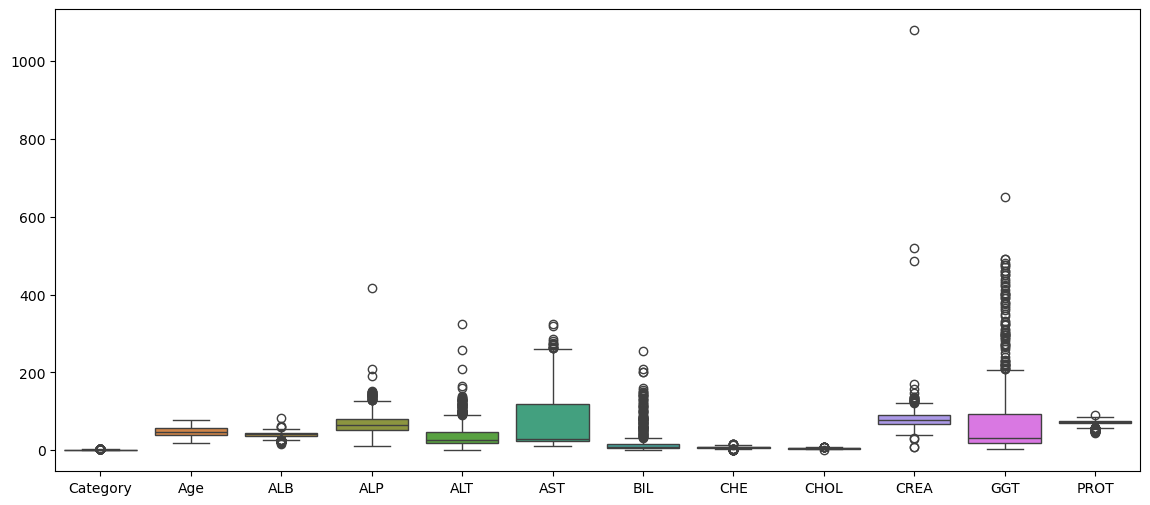

In [25]:
## Boxplot for determining the outliers visually 

plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.show()



### Interpretation of Each Feature’s Skewness

ALB: -0.44 → Slightly left-skewed, but close to normal.

ALP: 3.07 → Highly right-skewed, long tail on right.

ALT: 2.56 → Highly right-skewed.

AST: 1.37 → Moderately right-skewed.

BIL: 3.68 → Highly right-skewed.

CHE: -0.37 → Almost symmetric, tiny left skew.

CHOL: 0.27 → Very close to normal, slight right skew.

CREA: 16.24  → Extremely right-skewed (lots of outliers).

GGT: 2.38 → Highly right-skewed.

PROT: -1.00 → Moderately left-skewed.

# **Final Data Cleaning**

In [26]:
#Drop Sex Column as it is least correalted and not useful while training the model

df.drop(columns=['Sex'], inplace=True)

# **Calculating IQR and Z-Score**

In [27]:
#Calculating IQR and Z-Score to check the outliers and treat them if needed

# Calculating the IQR for ALB feature, by finding the Q1 and Q3. 

Q1 = df['ALB'].quantile(0.25)
Q3 = df['ALB'].quantile(0.75)

print(Q1)
print(Q3)

37.8
45.0


In [28]:
#Calculate IQR
# IQR = Q3 - Q1

IQR = Q3 - Q1

#Calculating Lower and Upper Bound 

lower = Q1 - 1.5* IQR
upper = Q3 + 1.5* IQR

#Calculate Outliers 

outliers =[]

for i in df['ALB']:
    if i < lower or i > upper:
        outliers.append(i)


        
outliers_count = len(outliers)

print(outliers_count)      

# Calculate the percentage of outliers 

total_rows = len(df)
outliers_percent = (outliers_count * 100)/total_rows

print(outliers_percent)




37
4.539877300613497


### By calculating the same way for all the features, this is the outlier percentage. 

In [29]:
import pandas as pd

# Creating the DataFrame using series-like style
outliers_df = pd.DataFrame({
    'Parameter': pd.Series(['ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']),
    'Outliers_Count': pd.Series([37.0, 31.0, 64.0, 13.0, 91.0, 36.0, 11.0, 25.0, 73.0, 37.0]),
    'Total_Rows': pd.Series([815.0]*10),
    'Outliers_%': pd.Series([4.539877, 3.803681, 7.852761, 1.595092, 11.165644, 4.417178, 1.349693, 3.067485, 8.957055, 4.539877])
})

# Display the DataFrame
outliers_df

,Parameter,Outliers_Count,Total_Rows,Outliers_%
0,ALB,37.0,815.0,4.539877
1,ALP,31.0,815.0,3.803681
2,ALT,64.0,815.0,7.852761
3,AST,13.0,815.0,1.595092
4,BIL,91.0,815.0,11.165644
5,CHE,36.0,815.0,4.417178
6,CHOL,11.0,815.0,1.349693
7,CREA,25.0,815.0,3.067485
8,GGT,73.0,815.0,8.957055
9,PROT,37.0,815.0,4.539877


## As there is no feature that consist of more than 20% of the outliers, so it is not neccessary to treat, as these values are significant for training the model.



# **Train_Test_Split**

In [30]:
# importing train_test_split from sklearn library's model_selection module

from sklearn.model_selection import train_test_split

# Spliting Features and Target in to variable

x=df.iloc[:,1:12]
y = df['Category']

#Splitting the test and train data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)


# **Standardization**



In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)  # Fit on training data
x_test = scaler.transform(x_test)        # Transform test data


# **Cross Validation**

In [32]:
## Using Cross Validation to find to which Model is perfect for data set. 
# It is significant for saving time and instead of using all the models, it helps in selecting the only model to train on  our dataset.

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


models = {'LR': LogisticRegression(),
          'RF' : RandomForestClassifier(),
          'NB' : GaussianNB(),
          'svc' : SVC(),
          'knn' : KNeighborsClassifier()
}


cv_results={}
for name, model in models.items():
    scores = cross_val_score(model, x_train,y_train,cv=3, scoring='accuracy')
    cv_results[name] = scores.mean()

print(cv_results)

{'LR': 0.9315789473684211, 'RF': 0.936842105263158, 'NB': 0.9087719298245615, 'svc': 0.9280701754385965, 'knn': 0.9280701754385965}


# **Outcome : -**

### The Cross Validation step is a crucial part of building a Machine Learning Model.
### The outcome of our observation has favoured RandomForestClassifier as it has the highest accuracy of approximately 93%.
### Thus, Making it easy for us to select a single model.



# **Build Model**

In [33]:

from sklearn.model_selection import RandomizedSearchCV


rf_model= RandomForestClassifier()

para = {
    'n_estimators': [100,150,200,250,300],   
    'max_depth': [None, 10,15,20,25],
    'min_samples_split': [2, 3,5,10,12],     
    'bootstrap': [True,False]
}


random_cv= RandomizedSearchCV(estimator=rf_model, param_distributions=para, cv=5, verbose=2, n_iter=25,random_state=42, n_jobs=-1)

random_cv.fit(x_train,y_train)


random_cv.best_params_



Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


{'n_estimators': 150,
 'min_samples_split': 3,
 'max_depth': 15,
 'bootstrap': False}

# **Predicting / Evaluating the Model**


In [34]:
y_pred = random_cv.predict(x_test)



# **Checking the Model Accuracy**


In [35]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9714285714285714


# **Validation**

In [36]:
# Suppose your new sample has 10 feature values
new_patient = [[45, 3.0, 150, 85, 90, 21.2, 7500, 60, 7.0, 180, 1.0]]

new_patient_scaled = scaler.transform(new_patient)  # use the same scaler from training


# Predict
prediction = random_cv.predict(new_patient_scaled)

actual_disease = encoder.inverse_transform(prediction)
print("Patient has :", actual_disease[0])


Patient has : Cirrhosis


c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([('scaler',scaler), ('model', random_cv.best_estimator_)])


In [38]:
import joblib

joblib.dump(final_pipeline, "liver_pipeline.pkl")

joblib.dump(encoder,"Label_Encoder.pkl")


['Label_Encoder.pkl']

In [39]:
# Load back and test
loaded_pipeline = joblib.load("liver_pipeline.pkl")
loaded_encoder = joblib.load("Label_encoder.pkl")

test_pred = loaded_pipeline.predict(new_patient)
print("Prediction after reload:", loaded_encoder.inverse_transform(test_pred)[0])


Prediction after reload: Cirrhosis


c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import sys
print(sys.executable)

c:\Users\aryan\anaconda3\python.exe


In [ ]:
import shap
print("SHAP working")

SHAP working


In [42]:
import joblib

pipeline = joblib.load("liver_pipeline.pkl")
model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]

feature_names = ['Age','ALB','ALP','ALT','AST','BIL','CHE','CHOL','CREA','GGT','PROT']

In [41]:
prediction = pipeline.predict(input_data)[0]
print(prediction)

0


c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
label_encoder = joblib.load("Label_Encoder.pkl")
decoded_prediction = label_encoder.inverse_transform([prediction])[0]
print(decoded_prediction)

Blood Donor


In [53]:
import shap
import matplotlib.pyplot as plt
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
import joblib
import numpy as np
from datetime import datetime

pipeline = joblib.load("liver_pipeline.pkl")
model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]
label_encoder = joblib.load("Label_Encoder.pkl")

feature_names = ['Age','ALB','ALP','ALT','AST','BIL','CHE','CHOL','CREA','GGT','PROT']

prediction = pipeline.predict(input_data)[0]
decoded_prediction = label_encoder.inverse_transform([prediction])[0]

explainer = shap.Explainer(model)
shap_values = explainer(input_data)

# select correct class explanation
single_explanation = shap_values[0, :, prediction]

# ✅ ADD THIS (IMPORTANT FIX)
single_explanation.feature_names = [
    "Age",
    "Albumin",
    "Alkaline Phosphatase",
    "Alanine Aminotransferase",
    "Aspartate Aminotransferase",
    "Bilirubin",
    "Cholinesterase",
    "Cholesterol",
    "Creatinine",
    "Gamma-Glutamyl Transferase",
    "Total Protein"
]

shap_vals = single_explanation.values

def generate_explanation(feature_names, shap_vals, input_data):
    explanation = []
    for i in range(len(feature_names)):
        val = float(shap_vals[i])
        name = feature_names[i]
        actual = input_data[0][i]
        if val > 0:
            explanation.append(f"{name} ({actual}) increased risk")
        else:
            explanation.append(f"{name} ({actual}) reduced risk")
    return explanation

explanation = generate_explanation(feature_names, shap_vals, input_data)

# SHAP plot
shap.plots.waterfall(single_explanation, show=False)
plt.savefig("shap_plot.png", bbox_inches='tight')
plt.close()

doc = SimpleDocTemplate("Liver_Report.pdf")
styles = getSampleStyleSheet()

content = []

content.append(Paragraph("Liver Disease Clinical Report", styles['Title']))
content.append(Spacer(1, 20))

content.append(Paragraph(f"Generated on: {datetime.now()}", styles['Normal']))
content.append(Spacer(1, 20))

content.append(Paragraph("Patient Biomarkers", styles['Heading2']))
for i in range(len(feature_names)):
    content.append(Paragraph(f"{feature_names[i]}: {input_data[0][i]}", styles['Normal']))

content.append(Spacer(1, 20))

content.append(Paragraph(f"Diagnosis: {decoded_prediction}", styles['Heading2']))

if decoded_prediction == "Cirrhosis":
    risk = "High Risk"
elif decoded_prediction in ["Fibrosis", "Hepatitis"]:
    risk = "Moderate Risk"
else:
    risk = "Low Risk"

content.append(Paragraph(f"Risk Level: {risk}", styles['Heading2']))

content.append(Spacer(1, 20))

content.append(Paragraph("AI Explanation", styles['Heading2']))
for line in explanation:
    content.append(Paragraph(line, styles['Normal']))

content.append(Spacer(1, 20))

content.append(Paragraph("Recommendation", styles['Heading2']))
content.append(Paragraph("Consult a hepatologist and perform further liver function tests if required.", styles['Normal']))

content.append(Spacer(1, 20))

content.append(Image("shap_plot.png", width=400, height=200))

doc.build(content)

print("Final Clinical Report Generated")

c:\Users\aryan\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Final Clinical Report Generated
